In [2]:
import importlib
import DblAttTransGAT

# Reload the module
importlib.reload(DblAttTransGAT)

# Now load autoreload properly
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from torch_geometric.nn import GATConv
import torch.nn.functional as F

from torch.utils.data import DataLoader

import math
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Any

from DataEncoder import add_delta_time, deterministic_length_stratified_split, build_vocabs, compute_L_max
from DataEncoder import encode_numeric_features, encode_categorical_features, encode_time_targets, build_sequence_head, build_process_graph, time_cap
from DataEncoder import BPMOneShotDataset, audit_encoded_split, bpm_collate_fn
from DataEncoder import build_holdout_head, HoldoutGenerationDataset, bpm_collate_fn_hold

from DblAttTransGATRe import ActivityGATEncoder, move_batch_to_device, GraphSequenceDoubleAttentionConfig, build_bigram_prior, generate_full_log
from DblAttTransGATRe import build_model, compute_E_act_cache, build_optimizer, WarmupCosineScheduler, sanity_check_one_batch, EarlyStopping, train_one_epoch, evaluate
from DblAttTransGATRe import build_schedulers, load_for_inference, load_for_training, rmse_to_score

from Visualization import process_transformer_attention, extract_case_transformer_attention, process_graph_attention, extract_case_graph_attention, process_gat_attention
from Visualization import plot_dual_stage_attention_figure, build_legal_successor_attention_table, plot_combined_attention_mass, plot_combined_attention_mass_comparison
from Visualization import build_refinement_shift_table, plot_refinement_raincloud_panel
from Visualization import build_transition_rescue_rows_from_gen, plot_transition_rescue, plot_transition_rescue_stacked_area

from Evaluation import evaluate_comprehensive, evaluate_light

import os 
import shutil

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
#dataname = "helpdesk"
#dataname = "sepsis"
#dataname = "BPI13I"
dataname = "BPI13C"
#dataname = "BPI20"
#dataname = "BPI12W"
#dataname = "BPI12"
#dataname = "BPI17"

In [4]:
#event = pd.read_csv("../output/data_processed/" + dataname + "_train.csv")
hold = pd.read_csv("../output/data_processed/" + dataname + "_hold.csv")
train_df = pd.read_csv("../output/data_processed/" + dataname + "_train_split.csv")
val_df = pd.read_csv("../output/data_processed/" + dataname + "_val_split.csv")

In [5]:
#event = add_delta_time(event, 'case:concept:name', 'time:timestamp', new_col="delta_time", norm=False)
hold = add_delta_time(hold, 'case:concept:name', 'time:timestamp', new_col="delta_time", norm=False)

In [6]:
case_index = 'case:concept:name'
time_col = 'time:timestamp'
core_event = "concept:name"
delta_col='delta_time'

In [7]:
if dataname == "helpdesk":
    cat_cols_event = ['org:resource']
    num_cols_event = []
    cat_cols_seq = ['case:variant']
    num_cols_seq = []
elif dataname == "BPI12" or dataname == "BPI12W":
    event[case_index] = event[case_index].astype(str)
    hold[case_index] = hold[case_index].astype(str)
    #train_df[case_index] = train_df[case_index].astype(str)
    #val_df[case_index] = val_df[case_index].astype(str)
    cat_cols_event = ['org:resource']
    num_cols_event = []
    cat_cols_seq = []
    num_cols_seq = ['case:AMOUNT_REQ']
elif dataname == "BPI13I" or dataname == "BPI13C":
    cat_cols_event = ['org:group', "resource country", "org:resource", "organization involved", "org:role"]
    num_cols_event = []
    cat_cols_seq = ["organization country", "impact", "product"]
    num_cols_seq = []
elif dataname == "sepsis":
    cat_cols_event = ['org:group']
    num_cols_event = ['Leucocytes', 'CRP', 'LacticAcid']
    cat_cols_seq = ['InfectionSuspected', 'DiagnosticBlood',     'DisfuncOrg',  'SIRSCritTachypnea', 'Hypotensie',       'SIRSCritHeartRate', 
                    'Infusion',           'DiagnosticArtAstrup', 'DiagnosticIC', 'DiagnosticSputum', 'DiagnosticLiquor', 'DiagnosticOther',
                    'SIRSCriteria2OrMore', 'DiagnosticXthorax',  'SIRSCritTemperature', 'DiagnosticUrinaryCulture', 'SIRSCritLeucos', 'Oligurie', 
                    'DiagnosticLacticAcid', 'Diagnose',          'Hypoxie',             'DiagnosticUrinarySediment', 'DiagnosticECG']
    num_cols_seq = [ 'Age']
elif dataname == "BPI17":
    cat_cols_event = ['Action', 'org:resource', 'EventOrigin', 'Accepted', 'Selected', "OfferID"]
    num_cols_event = ['FirstWithdrawalAmount', 'NumberOfTerms', 'MonthlyCost',  'CreditScore', 'OfferedAmount']
    cat_cols_seq = [ 'case:LoanGoal', 'case:ApplicationType']
    num_cols_seq = ['case:RequestedAmount']
elif dataname == "BPI20":
    cat_cols_event = ['org:role']
    num_cols_event = []
    cat_cols_seq = ["case:OrganizationalEntity", "case:Project"]
    num_cols_seq = ["case:RequestedAmount", "case:Permit RequestedBudget"]  

In [148]:
# Use stratified sampling over sequence length to preserve distributional characteristics
train_indices, val_indices = deterministic_length_stratified_split(event, case_index, core_event, test_size=0.2, n_bins=10,  random_state=42, verbose=True)

train_df = event[event[case_index].isin(train_indices)]
val_df = event[event[case_index].isin(val_indices)]

case_lengths = event.groupby(case_index).size()
train_lengths = case_lengths.loc[train_indices]
val_lengths  = case_lengths.loc[val_indices]

print(f"Train set: {len(train_indices)} samples")
print(f"Train length range: {min(train_lengths)} - {max(train_lengths)}")
print(f"Train length mean: {np.mean(train_lengths):.2f}")

print(f"\nTest set: {len(val_indices)} samples") 
print(f"Test length range: {min(val_lengths)} - {max(val_lengths)}")
print(f"Test length mean: {np.mean(val_lengths):.2f}")

train_df.to_csv("../output/data_processed/" + dataname + "_train_split.csv", index=False)
val_df.to_csv("../output/data_processed/" + dataname + "_val_split.csv", index=False)

NameError: name 'event' is not defined

In [8]:
#compute the longest case
L_max = compute_L_max(train_df, case_index, True)

In [9]:
# vacabulary for categorical data
vocabs = build_vocabs(train_df, core_event, cat_cols_event, cat_cols_seq, True, True,True)

In [10]:
event_num_tr, seq_num_tr, num_stats = encode_numeric_features(train_df, case_index, time_col, num_cols_event, num_cols_seq, L_max, stats=None, fit=True)
event_num_val, seq_num_val, _ = encode_numeric_features(val_df, case_index, time_col, num_cols_event, num_cols_seq, L_max, stats=num_stats, fit=False)

In [11]:
activity_tr, event_cat_tr, seq_cat_tr, mask_tr, lengths_tr = encode_categorical_features(train_df, case_index, time_col, 
                                                                                        core_event, cat_cols_event, cat_cols_seq, vocabs, L_max)
activity_val, event_cat_val, seq_cat_val, mask_val, lengths_val = encode_categorical_features(val_df, case_index, time_col,
                                                                                              core_event, cat_cols_event, cat_cols_seq, vocabs, L_max)

In [12]:
time_log_tr, time_stats = encode_time_targets(train_df, case_index, time_col, delta_col, L_max, stats=None, fit=True)
time_log_val, _ = encode_time_targets(val_df, case_index, time_col, delta_col, L_max, stats=time_stats, fit=False)

time_min_scaled, time_max_scaled = time_cap(train_df, delta_col, time_stats)

In [13]:
seq_head_tr, case_ids_tr, start_times_tr = build_sequence_head(train_df, case_index, time_col, lengths_tr, L_max)
seq_head_val, case_ids_val, start_times_val = build_sequence_head(val_df, case_index, time_col, lengths_val, L_max)

In [14]:
train_dataset = BPMOneShotDataset(seq_head_tr, seq_cat_tr, seq_num_tr, activity_tr, time_log_tr, event_cat_tr, event_num_tr, mask_tr, lengths_tr, case_ids_tr, start_times_tr)
val_dataset = BPMOneShotDataset(seq_head_val, seq_cat_val, seq_num_val, activity_val, time_log_val, event_cat_val, event_num_val, mask_val, lengths_val, case_ids_val, start_times_val)

In [15]:
train_encoded = {
    "seq_head": seq_head_tr,
    "mask": mask_tr,
    "lengths": lengths_tr,
    "y_activity": activity_tr,
    "y_time_log": time_log_tr,
    "seq_cat": seq_cat_tr,
    "event_cat": event_cat_tr,
    "seq_numeric": seq_num_tr,
    "event_numeric": event_num_tr,
}

audit_encoded_split("TRAIN", train_encoded, vocabs)


========== AUDIT: TRAIN ==========
N cases: 1072 | L_max: 36
seq_head: ((1072, 5), torch.float32)
mask: ((1072, 36), torch.float32)
lengths: ((1072,), torch.int64)
y_activity: ((1072, 36), torch.int64)
y_time_log: ((1072, 36), torch.float32)
Max raw length: 36
Cases truncated: 0

Seq categorical cols: ['organization country', 'impact', 'product']
  seq_cat[organization country]: ((1072,), torch.int64)
  seq_cat[impact]: ((1072,), torch.int64)
  seq_cat[product]: ((1072,), torch.int64)

Event categorical cols: ['org:group', 'resource country', 'org:resource', 'organization involved', 'org:role']
  event_cat[org:group]: ((1072, 36), torch.int64)
  event_cat[resource country]: ((1072, 36), torch.int64)
  event_cat[org:resource]: ((1072, 36), torch.int64)
  event_cat[organization involved]: ((1072, 36), torch.int64)
  event_cat[org:role]: ((1072, 36), torch.int64)

Seq numeric cols: []

Event numeric cols: []

Mask summary:
  Valid positions: 5727
  Padded positions: 32865

========== AUD

In [16]:
val_encoded = {
    "seq_head": seq_head_val,
    "mask": mask_val,
    "lengths": lengths_val,
    "y_activity": activity_val,
    "y_time_log": time_log_val,
    "seq_cat": seq_cat_val,
    "event_cat": event_cat_val,
    "seq_numeric": seq_num_val,
    "event_numeric": event_num_val,
}

audit_encoded_split("VAL", val_encoded, vocabs)


========== AUDIT: VAL ==========
N cases: 267 | L_max: 36
seq_head: ((267, 5), torch.float32)
mask: ((267, 36), torch.float32)
lengths: ((267,), torch.int64)
y_activity: ((267, 36), torch.int64)
y_time_log: ((267, 36), torch.float32)
Max raw length: 20
Cases truncated: 0

Seq categorical cols: ['organization country', 'impact', 'product']
  seq_cat[organization country]: ((267,), torch.int64)
  seq_cat[impact]: ((267,), torch.int64)
  seq_cat[product]: ((267,), torch.int64)

Event categorical cols: ['org:group', 'resource country', 'org:resource', 'organization involved', 'org:role']
  event_cat[org:group]: ((267, 36), torch.int64)
  event_cat[resource country]: ((267, 36), torch.int64)
  event_cat[org:resource]: ((267, 36), torch.int64)
  event_cat[organization involved]: ((267, 36), torch.int64)
  event_cat[org:role]: ((267, 36), torch.int64)

Seq numeric cols: []

Event numeric cols: []

Mask summary:
  Valid positions: 1558
  Padded positions: 8054

========== AUDIT PASSED =======

In [17]:
head_graph_tr = build_process_graph(train_df, core_event, case_index, time_col, delta_col, vocabs)

In [18]:
model_cfg = {
    # sequence length
    "L_max": int(L_max),
    # activity (graph + classifier)
    "num_activities": len(vocabs["activity"]),
    "pad_id": vocabs["activity"]["<PAD>"],
    "unk_id": vocabs["activity"]["<UNK>"],
    "eos_id": vocabs["activity"]["<EOS>"],
    "sos_id": vocabs["activity"]["<SOS>"],
    # case numeric conditioning
    "d_case_num": seq_head_tr.shape[1],  # length_norm + 4 time dims (+ any seq numeric)
    # sequence categorical (case-level) vocab sizes
    "seq_cat_vocab_sizes": { c: len(vocabs["seq_cat"][c]) for c in vocabs["seq_cat"]},
    # event categorical (per-timestep) vocab sizes
    "event_cat_vocab_sizes": { c: len(vocabs["event_cat"][c]) for c in vocabs["event_cat"]},
    # event numeric dims (per-timestep)
    "event_num_cols": list(event_num_tr.keys()),  
    # sequence numeric dims (case-level)
    "seq_num_cols": list(seq_num_tr.keys()),  
    # graph edge features
    "edge_attr_dim": int(head_graph_tr["edge_attr"].shape[1]),
}

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

d_model = 256

gat_encoder = ActivityGATEncoder(
        num_activities = model_cfg["num_activities"],
        d_model = d_model,    
        edge_dim = model_cfg["edge_attr_dim"],
        num_layers = 2,
        heads = 4,
        dropout = 0.05,
        use_norm = True,
        init_scale = 0.01
).to(device)

edge_index = head_graph_tr["edge_index"].to(device)
edge_attr = head_graph_tr["edge_attr"].to(device)

E_act, ei_head, alpha_head = gat_encoder(edge_index, edge_attr, return_attention=True)

In [20]:
if dataname == "sepsis":
    w_event_cat = 0.15
    w_event_num = 0.1
    # case (sequence-level) prediction weights
    w_seq_cat = 0.05
    w_seq_num = 0.05
    unary_weight = 0.55
elif dataname == "BPI17":
    w_event_cat = 0.15
    w_event_num = 0.1
    # case (sequence-level) prediction weights
    w_seq_cat = 0.05
    w_seq_num = 0.05
    unary_weight = 0.55
elif dataname == "helpdesk":
    w_event_cat = 0.8
    w_event_num = 0
    # case (sequence-level) prediction weights
    w_seq_cat = 0.5
    w_seq_num = 0
    unary_weight = 0.55
elif dataname == "BPI12" or dataname == "BPI12W" :
    w_event_cat = 0.1
    w_event_num = 0
    # case (sequence-level) prediction weights
    w_seq_cat = 0
    w_seq_num = 0.05
    unary_weight = 0.55
elif dataname == "BPI13I" or dataname == "BPI13C":
    w_event_cat = 0.15
    w_event_num = 0
    # case (sequence-level) prediction weights
    w_seq_cat = 0.05
    w_seq_num = 0
    if dataname == "BPI13I":
       unary_weight = 3
    elif dataname == "BPI13C":
       unary_weight = 0.55 
elif dataname == "BPI20":
    w_event_cat = 0.15
    w_event_num = 0
    # case (sequence-level) prediction weights
    w_seq_cat = 0.05
    w_seq_num = 0.05
    unary_weight = 0.55

In [21]:
model = build_model(
    L_max = model_cfg["L_max"],                         # your padded max trace length
    num_activities = model_cfg["num_activities"],   # activity vocabulary size
    d_case_num = model_cfg['d_case_num'],          # case feature dimension
    d_model = d_model,
    n_layers = 4,
    de_layers = 2,
    n_heads = 4,
    dropout = 0.2,
    ff_mult = 4,
    ff_mult_x = 4,
    gate_init = 0.05,
    length_bins = model_cfg["L_max"], 
    
    # keep them as default 
    latent_dim = 0,                             # keep OFF 
    latent_std = 1.0,
    # loss weights
    w_activity = 1.0,
    w_time = 0.1,
    w_length = 0.25,
    w_event_cat = w_event_cat,
    w_event_num = w_event_num,
    # case (sequence-level) prediction weights
    w_seq_cat = w_seq_cat,
    w_seq_num = w_seq_num,
    w_transition_penalty = 0,
    # decoding stabilizer
    use_activity_bias = True,
    # activity ids reserved
    pad_id = 0,
    unk_id = 1,
    eos_id = 2,
    sos_id = 3,
    
    # head
    activity_decoder = "cosine_linear",  # allow values "cosine_linear", "cosine", "linear"
    
    # final activity setup
    w_final_activity = 5.0,
    w_preterminal_activity = 3.0,
    use_activity_feedback=False,
    n_refine_layers=1,
    activity_feedback_gate_init=0.3,
    activity_feedback_temp=1,
    use_transition_bias = True,
    transition_bias_weight = 0.5,
    #default
    #unary_weight = 0.55,
    #for bpi13I
    unary_weight = unary_weight,

    # optional
    event_cat_dims = model_cfg["event_cat_vocab_sizes"] ,
    event_num_names = model_cfg['event_num_cols'],
    seq_cat_dims=model_cfg["seq_cat_vocab_sizes"],
    seq_num_names=model_cfg["seq_num_cols"]
    
).to(device)


In [22]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,          # set >0 later if stable
    pin_memory=True,
    collate_fn=bpm_collate_fn,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=bpm_collate_fn,
    drop_last=False,
)

In [23]:
optimizer = build_optimizer(
    seq_model=model,
    lr_base=2e-4,
    weight_decay= 3e-4
)

In [24]:
num_epochs = 300
scheduler_epochs = 300
steps_per_epoch = len(train_loader)
#total_steps = steps_per_epoch * num_epochs
total_steps = steps_per_epoch * scheduler_epochs
warmup_steps = int(0.05 * total_steps)

scheduler = WarmupCosineScheduler(
    optimizer,
    warmup_steps=warmup_steps,
    total_steps=total_steps,
    min_lr_mult=0.1
)

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sanity_check_one_batch(
    gat_encoder=gat_encoder,
    seq_model=model,
    train_loader=train_loader,
    head_graph=head_graph_tr,
    device=device,
)

=== SANITY CHECK START ===
E_act shape: (11, 256)
E_act check OK
Batch size: 64
Seq length: 36
activity_logits shape: (64, 36, 11)
Activity logits check OK
time_pred shape: (64, 36)
length_logits shape: (64, 36)
=== SANITY CHECK PASSED ===


In [26]:
attn_save_path = "../output/checkpoints/" + dataname + "_best_attention0.pt"
history_path = "../output/checkpoints/" + dataname + "_history0.pt"
model_path = "../output/checkpoints/" + dataname + "_double_attention_best_model0.pt"
early_stopper = EarlyStopping(patience=40, checkpoint_path=model_path)

history = {
    "train_loss": [],
    "val_loss": [],
    
    "train_act_acc": [],
    "val_act_acc": [],

    "train_act_no_eos_acc": [],
    "val_act_no_eos_acc": [],

    "train_act_final_acc": [],
    "val_act_final_acc": [],

    "train_act_preterm_acc": [],
    "val_act_preterm_acc": [],
    
    "train_len_acc": [],
    "val_len_acc": [],
    
    "train_time_rmse": [],
    "val_time_rmse": [],
    
    "train_event_cat_acc": [],
    "val_event_cat_acc": [],
    
    "train_event_num_rmse": [],
    "val_event_num_rmse": [],
    
    "train_seq_cat_acc": [],
    "val_seq_cat_acc": [],
    
    "train_seq_num_rmse": [],
    "val_seq_num_rmse": [],
    
    "lr": [],

    "train_E_act": [],
    "val_E_act": []
    
}

for epoch in range(num_epochs):

    train_loss, train_acc, train_no_eos_acc, train_final_acc, train_preterm_acc, train_len_acc, train_time_rmse, train_event_acc, train_event_rmse, train_seq_acc, train_seq_rmse, train_E_act, train_attn = train_one_epoch(
        model, gat_encoder, train_loader, head_graph_tr,
        optimizer, scheduler,device, epoch,
        capture_attn=True,
        attn_batch_idx=epoch % len(train_loader)
    )

    val_loss, val_acc, val_no_eos_acc, val_final_acc, val_preterm_acc,val_len_acc, val_time_rmse, val_event_acc, val_event_rmse, val_seq_acc, val_seq_rmse, val_E_act, val_attn = evaluate(
        model, gat_encoder, val_loader, head_graph_tr,
        device,
        capture_attn=True,
        attn_batch_idx=epoch % len(val_loader)
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    
    history["train_act_acc"].append(train_acc)
    history["val_act_acc"].append(val_acc)

    history["train_act_no_eos_acc"].append(train_no_eos_acc)
    history["val_act_no_eos_acc"].append(val_no_eos_acc)
    
    history["train_act_final_acc"].append(train_final_acc)
    history["val_act_final_acc"].append(val_final_acc)

    history["train_act_preterm_acc"].append(train_preterm_acc)
    history["val_act_preterm_acc"].append(val_preterm_acc)
    
    history["train_len_acc"].append(train_len_acc)
    history["val_len_acc"].append(val_len_acc)
    
    history["train_time_rmse"].append(train_time_rmse)
    history["val_time_rmse"].append(val_time_rmse)
    
    history["train_event_cat_acc"].append(train_event_acc)
    history["val_event_cat_acc"].append(val_event_acc)
    
    history["train_event_num_rmse"].append(train_event_rmse)
    history["val_event_num_rmse"].append(val_event_rmse)
    
    history["train_seq_cat_acc"].append(train_seq_acc)
    history["val_seq_cat_acc"].append(val_seq_acc)
    
    history["train_seq_num_rmse"].append(train_seq_rmse)
    history["val_seq_num_rmse"].append(val_seq_rmse)
    
    history["lr"].append(current_lr)

    history["train_E_act"].append(train_E_act.numpy())
    history["val_E_act"].append(val_E_act.numpy())


    evt_num_s = rmse_to_score(val_event_rmse, c=1.0)
    seq_num_s = rmse_to_score(val_seq_rmse, c=1.0)
    time_s = rmse_to_score(val_time_rmse, c=0.5)

    if dataname == "sepsis":
        val_score = (0.93 * val_no_eos_acc + 0.01 * val_seq_acc + 0.02 * val_event_acc + 0.01 * seq_num_s + 0.02 * evt_num_s + 0.01 * time_s)
    elif dataname == "BPI17":
        val_score = (0.93 * val_no_eos_acc + 0.01 * val_seq_acc + 0.02 * val_event_acc + 0.01 * seq_num_s + 0.02 * evt_num_s + 0.01 * time_s)
    elif dataname == "helpdesk":  
        val_score = 0.75 * val_no_eos_acc + 0.03 * val_seq_acc + 0.2 * val_event_acc + 0.02 * time_s
    elif dataname == "BPI12" or dataname == "BPI12W":  
        val_score = 0.93 * val_no_eos_acc + 0.02 * seq_num_s + 0.03 * val_event_acc + 0.02 * time_s
    elif dataname == "BPI13I" or dataname == "BPI13C":  
        val_score = 0.8 * val_no_eos_acc + 0.03 * val_seq_acc + 0.15 * val_event_acc + 0.02 * time_s
    elif dataname == "BPI20":
        val_score = 0.85 * val_no_eos_acc + 0.02 * val_seq_acc + 0.1 * val_event_acc + 0.02 * seq_num_s + 0.01 * time_s
    
    saved = early_stopper.step(val_score, val_no_eos_acc, model, gat_encoder, optimizer, scheduler, epoch)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Loss {train_loss:.4f}/{val_loss:.4f} | "
        f"ActAcc {train_acc:.4f}/{val_acc:.4f} | "
        f"ActNoEosAcc {train_no_eos_acc:.4f}/{val_no_eos_acc:.4f} | "
        f"ActFinalAcc {train_final_acc:.4f}/{val_final_acc:.4f} | "
        f"ActPretermAcc {train_preterm_acc:.4f}/{val_preterm_acc:.4f} | "
        f"LenAcc {train_len_acc:.4f}/{val_len_acc:.4f} | "
        f"TimeRMSE {train_time_rmse:.4f}/{val_time_rmse:.4f} | "
        f"EvtCat {train_event_acc:.4f}/{val_event_acc:.4f} | "
        f"EvtNum {train_event_rmse:.4f}/{val_event_rmse:.4f} | "
        f"SeqCat {train_seq_acc:.4f}/{val_seq_acc:.4f} | "
        f"SeqNum {train_seq_rmse:.4f}/{val_seq_rmse:.4f}"
    )
    
    # Example: inspect attention shapes once
    if epoch == 0 and train_attn is not None:
        if train_attn["gat_alpha"] is not None:
            print("GAT alpha:", tuple(train_attn["gat_alpha"].shape))

        if train_attn.get("encoder_attn") is not None:
            if isinstance(train_attn["encoder_attn"], list):
                print("Encoder attn (last):", tuple(train_attn["encoder_attn"][-1].shape))

        if train_attn["transformer_attn"] is not None:
            if isinstance(train_attn["transformer_attn"], list):
                print("Transformer attn (last):", tuple(train_attn["transformer_attn"][-1].shape))
        if train_attn["graph_attn"] is not None:
            print("Graph cross attn:", tuple(train_attn["graph_attn"].shape))

            

    if saved:
        print(">>> New best model saved.")
    
        attn_pack = {
            "epoch": epoch,
            "attn_batch_idx": epoch % len(val_loader),
            "val_acc": val_acc,
            "val_no_eos_acc": val_no_eos_acc,
            "val_time_rmse": val_time_rmse,
            "val_event_acc": val_event_acc,
            "val_event_rmse": val_event_rmse,           
            "val_seq_acc": val_seq_acc,
            "val_seq_rmse": val_seq_rmse,
            "best_score": val_score,
            "id2activity": head_graph_tr["id2activity"],
            "mask": val_attn["mask"].cpu() if val_attn and val_attn.get("mask") is not None else None,
            "y_activity": val_attn["y_activity"].cpu() if val_attn and val_attn.get("y_activity") is not None else None,
            "pred_activity": val_attn["pred_activity"].cpu() if val_attn and val_attn.get("pred_activity") is not None else None,
            "activity_logits_1": (val_attn["activity_logits_1"].cpu() if val_attn and val_attn.get("activity_logits_1") is not None else None),
            "activity_logits": (val_attn["activity_logits"].cpu() if val_attn and val_attn.get("activity_logits") is not None else None),
            "gat_edge_index": (val_attn["gat_edge_index"].detach().cpu()
                               if val_attn and val_attn.get("gat_edge_index") is not None
                               else None),
            "gat_alpha": (val_attn["gat_alpha"].detach().cpu() if val_attn and val_attn.get("gat_alpha") is not None else None),
            "encoder_attn": (
                [a.detach().cpu() for a in val_attn["encoder_attn"]]
                if val_attn and isinstance(val_attn.get("encoder_attn"), list)
                else (val_attn["encoder_attn"].detach().cpu()
                      if val_attn and val_attn.get("encoder_attn") is not None
                      else None)
            ),
            
            "transformer_attn": (
                [a.detach().cpu() for a in val_attn["transformer_attn"]]
                if val_attn and isinstance(val_attn.get("transformer_attn"), list)
                else (val_attn["transformer_attn"].detach().cpu()
                      if val_attn and val_attn.get("transformer_attn") is not None
                      else None)
            ),
            "graph_attn": (val_attn["graph_attn"].detach().cpu() if val_attn and val_attn.get("graph_attn") is not None else None),
        }
        torch.save(attn_pack, attn_save_path)
        torch.save(history, history_path)

    if early_stopper.should_stop:
        print(f"\nEARLY STOPPING at epoch {epoch+1}")
        break


===== LOSS BREAKDOWN =====
loss: 4.3921
activity_loss: 2.6035
final_activity_loss: 2.8103
preterminal_activity_loss: 3.2559
time_loss: 0.6900
length_loss: 3.6393
transition_penalty: 0.0000
event_cat_loss: 4.2454
event_num_loss: 0.0000
seq_cat_loss: 3.4612
seq_num_loss: 0.0000

Epoch 001 | Loss 4.1504/3.4915 | ActAcc 0.2967/0.3963 | ActNoEosAcc 0.3248/0.3612 | ActFinalAcc 0.1758/0.5516 | ActPretermAcc 0.0537/0.0260 | LenAcc 0.0205/0.0339 | TimeRMSE 1.0649/1.0334 | EvtCat 0.0605/0.0911 | EvtNum 0.0000/0.0000 | SeqCat 0.0833/0.0940 | SeqNum 0.0000/0.0000
GAT alpha: (41, 4)
Encoder attn (last): (64, 4, 36, 36)
Transformer attn (last): (64, 4, 36, 36)
Graph cross attn: (64, 4, 36, 11)
>>> New best model saved.
Epoch 002 | Loss 3.2778/2.4854 | ActAcc 0.3570/0.5513 | ActNoEosAcc 0.2717/0.4619 | ActFinalAcc 0.7227/0.9505 | ActPretermAcc 0.1211/0.5062 | LenAcc 0.1553/0.4905 | TimeRMSE 1.0178/0.9138 | EvtCat 0.0979/0.1859 | EvtNum 0.0000/0.0000 | SeqCat 0.2083/0.2667 | SeqNum 0.0000/0.0000
>>> 

In [34]:
attn_save_path = "../output/checkpoints/" + dataname + "_best_attention.pt"
history_path = "../output/checkpoints/" + dataname + "_history.pt"
model_path = "../output/checkpoints/" + dataname + "_double_attention_best_model.pt"

In [27]:
checkpoint = load_for_inference(model, gat_encoder, model_path, device)
#checkpoint = load_for_training(model, gat_encoder, optimizer, scheduler, model_path, device)

print("Loaded best checkpoint from epoch:", checkpoint.get("epoch"), "Best score:", checkpoint.get("best_score"), "Best No EOS Act Acc:", checkpoint.get("best_act_acc"))

Loaded best checkpoint from epoch: 21 Best score: 0.7288991058941022 Best No EOS Act Acc: 0.8180887699127197


In [169]:
# pick a small batch from val_loader
#batch = next(iter(val_loader))
#batch = move_batch_to_device(batch, device)

In [28]:
seq_head_hd, case_ids_hd, start_times_hd, lengths_hd = build_holdout_head(hold, case_index, time_col, L_max)

hold_dataset = HoldoutGenerationDataset(seq_head_hd, lengths_hd, case_ids_hd, start_times_hd)

hold_loader = DataLoader(
    hold_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=bpm_collate_fn_hold,
    drop_last=False
)

In [29]:
bigram_prior = build_bigram_prior(
    train_df,
    case_index,
    core_event,
    time_col,
    act2id=vocabs["activity"],
    n_act=len(vocabs["activity"]),
    include_eos= True
)

In [37]:
if dataname == "BPI13I":
    temperature = 1
    greedy = True
    top_k = None
    time_sigma = 0.0
    adj_m = True
else:
    temperature = 1.5
    greedy = True
    top_k = None
    time_sigma  = 0.02
    adj_m = True

In [38]:
all_rows = []
all_rescue_rows = []
for batch in hold_loader:
    batch = move_batch_to_device(batch, device)
    df_batch, gen_batch = generate_full_log(model, gat_encoder, head_graph_tr, batch, device, vocabs, num_stats, time_stats, temperature, greedy, top_k, time_sigma, bigram_prior, time_min_scaled,
        time_max_scaled, adj_m)
    batch_rows = build_transition_rescue_rows_from_gen(
        gen=gen_batch,
        adj_matrix=head_graph_tr["adj_matrix"],
        pad_id=model.cfg.pad_id,
        unk_id=model.cfg.unk_id,
        eos_id=model.cfg.eos_id,
        sos_id=model.cfg.sos_id,
        top_k=top_k,
        n_bins=5,
    )

    all_rescue_rows.extend(batch_rows)
    all_rows.append(df_batch)

df_gen = pd.concat(all_rows, ignore_index=True)
df_rescue = pd.DataFrame(all_rescue_rows)

gen real lengths: [7, 9, 6, 13, 2, 5, 6, 8, 6, 6]
gen total lengths: [8, 10, 7, 14, 3, 6, 7, 9, 7, 7]
target real lens: [7, 9, 6, 13, 2, 5, 6, 8, 6, 6]


In [39]:
df_gen = df_gen.rename(columns={'case_id': 'case:concept:name', 'activity': 'concept:name', 'time_timestamp': 'time:timestamp'})
#df_gen.to_csv("../output/gen_traces/" + dataname + "_gen_gat.csv", index=False)

In [40]:
# Method 1: Using groupby and last()
#df_gen = df_gen.sort_values([case_index, time_col]).copy()
#result = df_gen.groupby(case_index)['concept:name'].last().eq('Closed').sum()
#print(f"Number of groups with last event 'Closed': {result}")

In [41]:
#df_gen = pd.read_csv("../output/gen_traces/" + dataname + "_gen_gat.csv")
df_gen = df_gen.sort_values([case_index, time_col]).copy()
hold = hold.sort_values([case_index, time_col]).copy()

In [ ]:
eval_light = evaluate_light(df_gen, hold, case_index, core_event, time_col, "pos", name="GGATN", jsd_lambda=1.0)

bol_cols_event = []
bol_cols_seq = []

eval_comp =evaluate_comprehensive(df_gen, hold, case_index, core_event, time_col, "pos", 
                       [core_event] + cat_cols_event, num_cols_event, bol_cols_event,
                       cat_cols_seq, num_cols_seq, bol_cols_seq,
                       name="GGATN", jsd_lambda=1.0
                      )
# Add metadata columns
eval_comp["length_bucket"] = "all"
eval_comp['data'] = dataname
eval_comp["num_cases"] = df_gen[case_index].nunique()
eval_comp = eval_comp.reset_index().rename(columns={'index': 'model'})

#eval_comp.to_csv("../output/metrics/" + dataname + "_eval.csv", index=False)

In [35]:
eval_comp["event_concept:name_accuracy_unconditional"]

0    0.380952
Name: event_concept:name_accuracy_unconditional, dtype: float64

In [36]:
print(eval_comp)

   model  seq_coverage  bigram_jsd_unconditional  \
0  GGATN           1.0                   0.37222   

   trace_similarity_unconditional  duration_wd_unconditional  \
0                        0.513748               1.812475e+07   

   dl_similarity_unconditional  bigram_jsd_conditional  \
0                     0.438911                 0.37222   

   trace_similarity_conditional  duration_wd_conditional  \
0                      0.513748             1.812475e+07   

   dl_similarity_conditional  ...  timestamp_mae_conditional  \
0                   0.438911  ...               9.463533e+06   

   seq_organization country_inconsistent_cases  \
0                                            0   

   seq_organization country_inconsistent_pct  seq_impact_inconsistent_cases  \
0                                        0.0                              0   

   seq_impact_inconsistent_pct  seq_product_inconsistent_cases  \
0                          0.0                               0   

   seq

In [180]:
all_eval = pd.read_csv("../output/metrics/" + dataname + "_eval.csv")
# Find the index of the matching row in all_eval
matching_index = all_eval[all_eval['model'] == "GGATN"].index
all_eval.loc[matching_index[0], eval_comp.columns] = eval_comp.iloc[0].values

In [181]:
all_eval.to_csv("../output/metrics/" + dataname + "_eval.csv", index = False)

In [ ]:
all_eval = pd.read_csv("../output/metrics/" + dataname + "_eval.csv")
all_eval = pd.concat([all_eval, eval_comp], ignore_index=True)
all_eval.to_csv("../output/metrics/" + dataname + "_eval.csv", index = False)

In [40]:
if dataname =="sepsis":
    m_len = 14
elif dataname == "helpdesk":
     m_len = 5
elif dataname == "BPI13I":
    m_len = 12
elif dataname == "BPI13C":
    m_len = 3
elif dataname == "BPI20":
    m_len = 8
elif dataname == "BPI12":
    m_len = 15

Saved: ../output/plots/sepsis_dual_stage_attention.png and ../output/plots/sepsis_dual_stage_attention.pdf


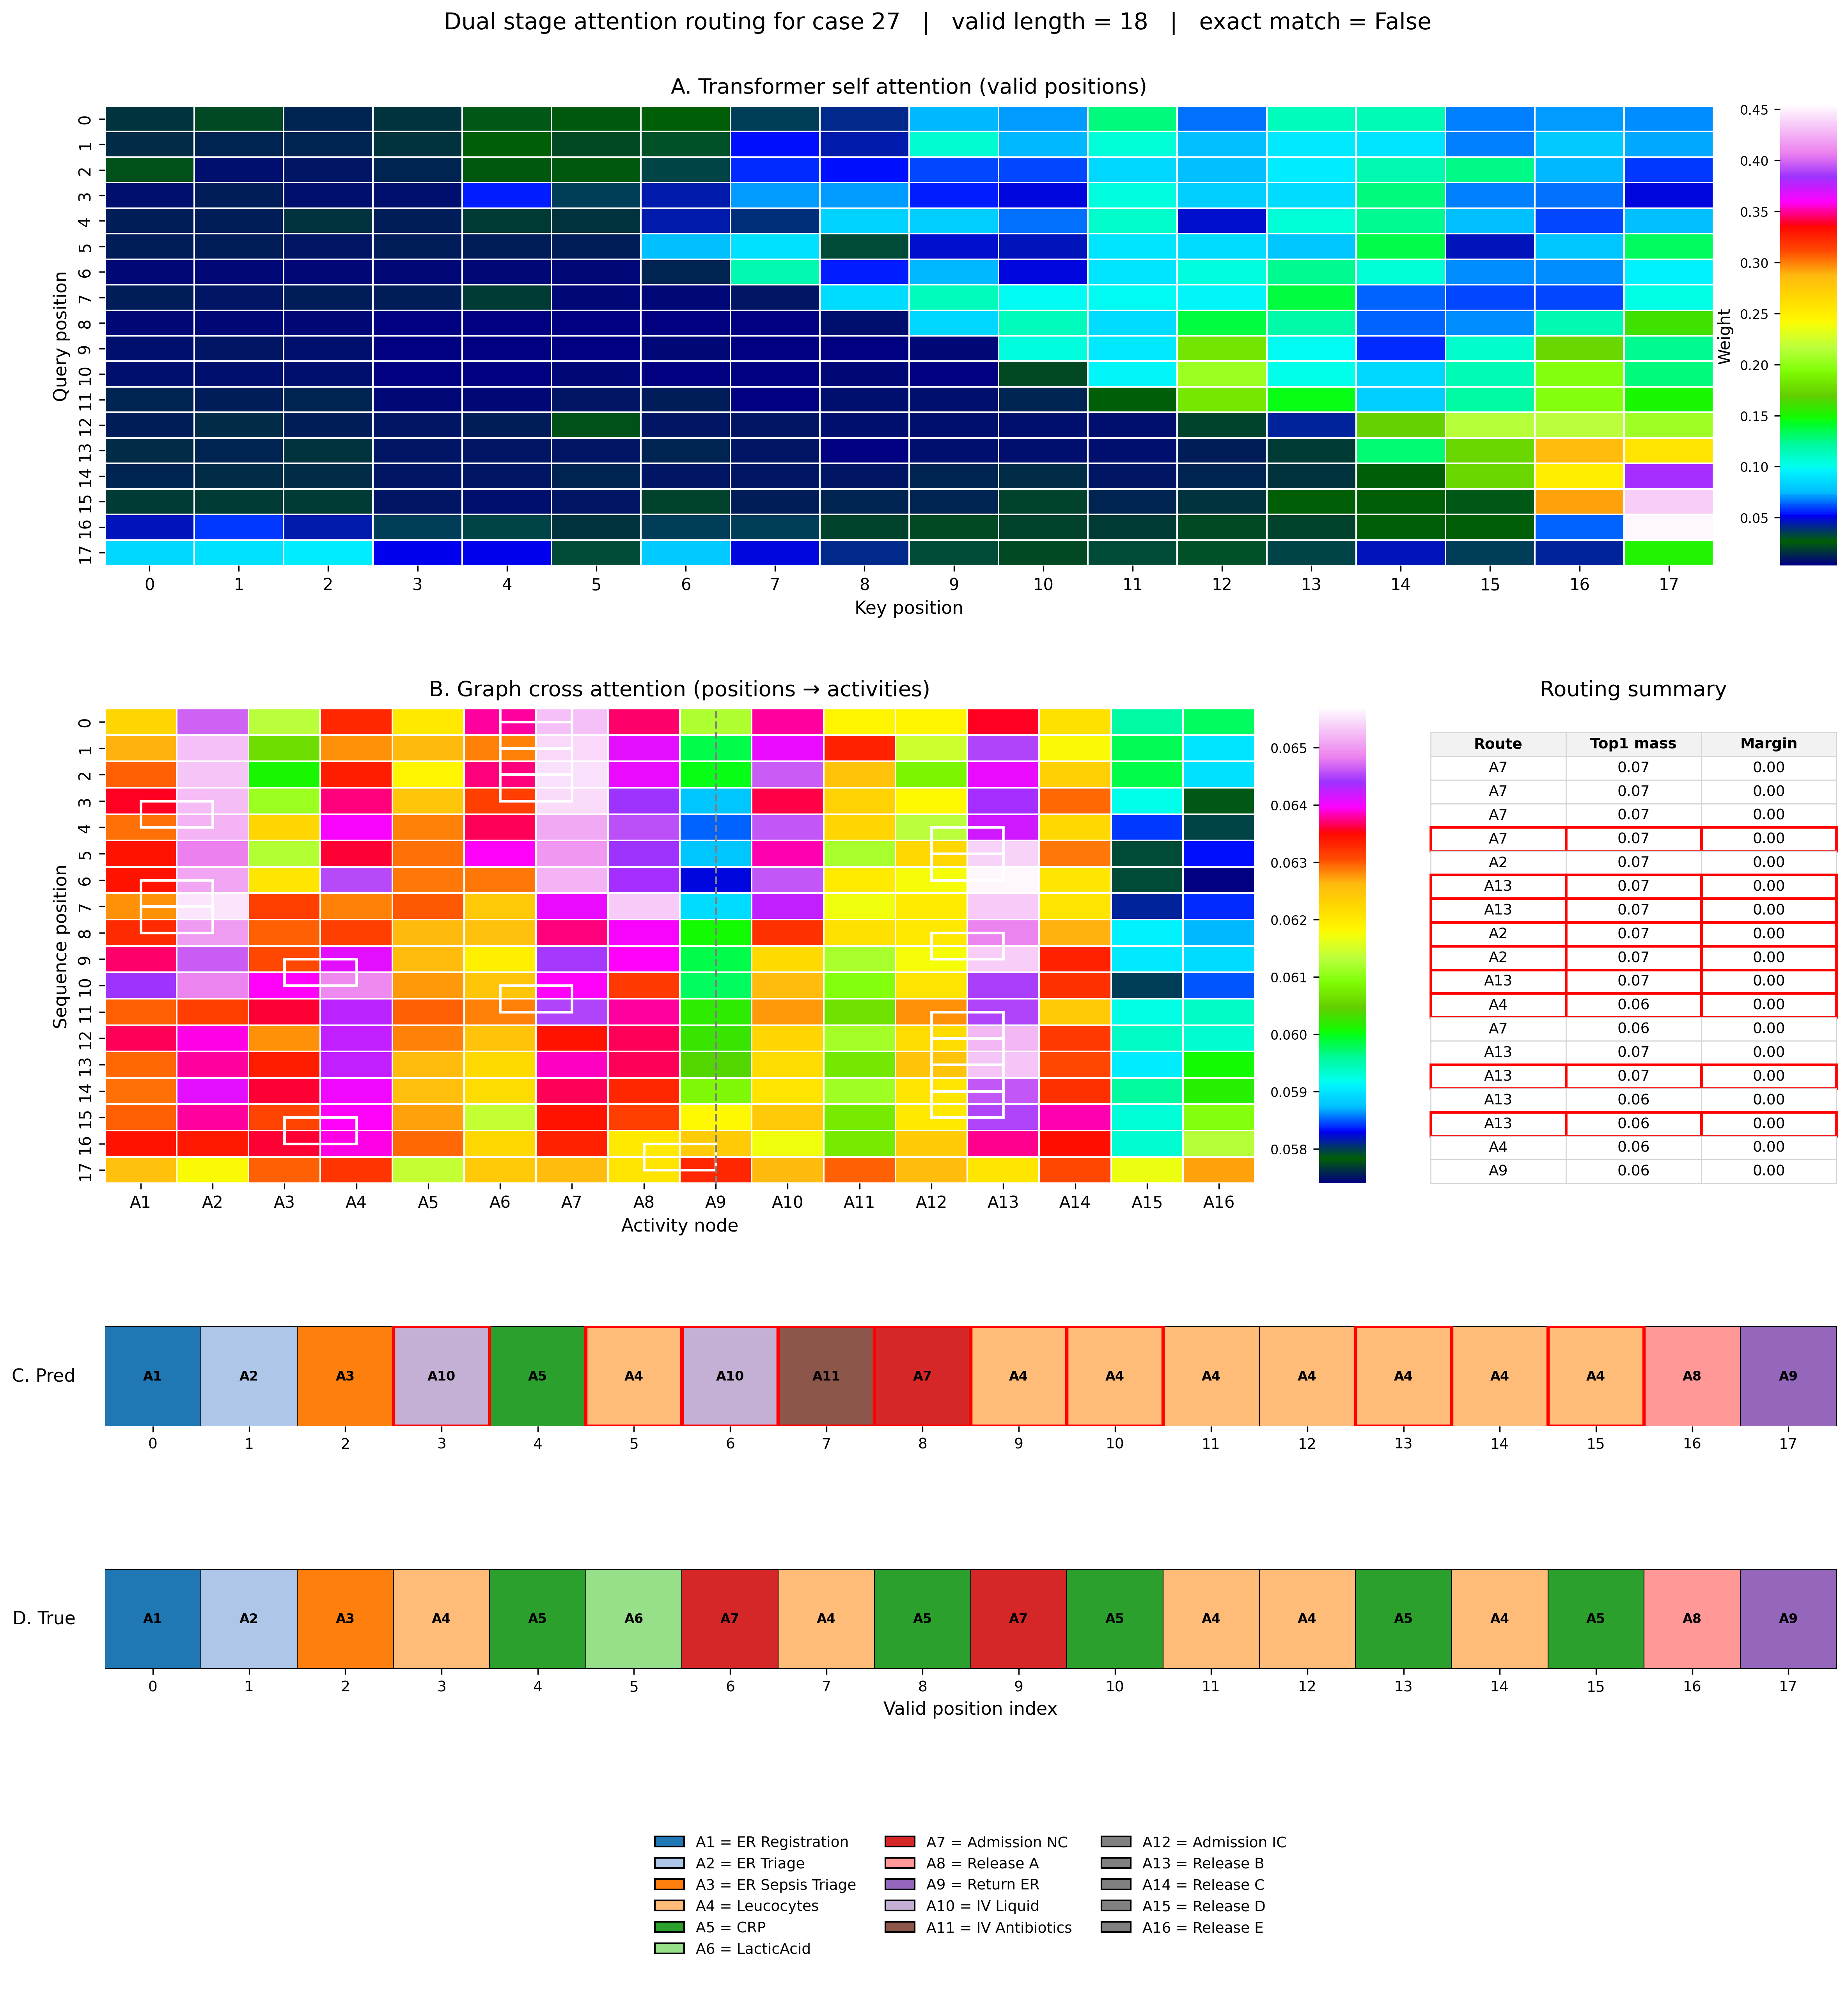

In [41]:
#attn_pack = torch.load(attn_save_path)
plot_dual_stage_attention_figure(
    attn_pack=attn_pack,
    case_index=None,
    min_len=m_len,
    save_path="../output/plots/" + dataname + "_dual_stage_attention",
    layer_mode="mean",
    tr_head_mode="mean",
    gx_head_mode="mean",
    remove_eos=True,
    figsize=(16,18),
    cmap_attn="gist_ncar"
)

Saved: ../output/plots/sepsis_attention_mass.png and ../output/plots/sepsis_attention_mass.pdf


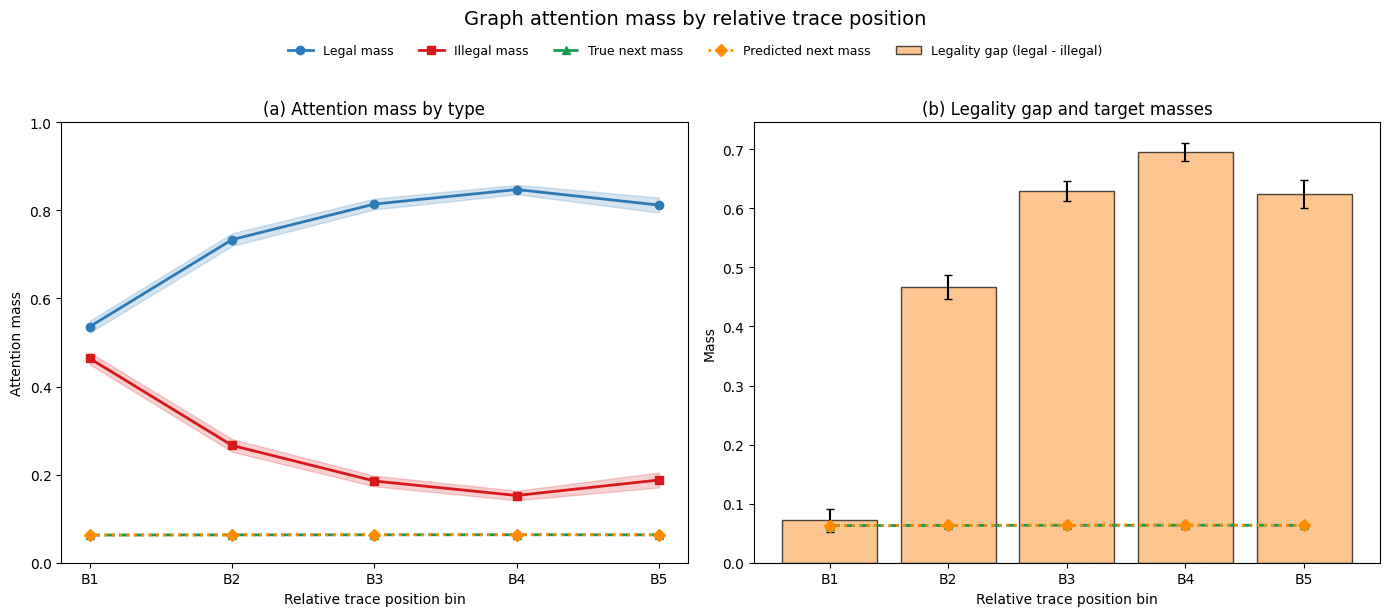

In [42]:
df_mass = build_legal_successor_attention_table(
     attn_pack=attn_pack,
     adj_matrix=head_graph_tr["adj_matrix"],
     num_activities=len(head_graph_tr["id2activity"]),
     pad_id=0,
     unk_id=1,
     eos_id=2,
     sos_id=3,
     n_bins=5,
     use_pred_as_current=False,
 )

df_mass.to_csv("../output/metrics/" + dataname + "_legal_successor_attention.csv", index=False)

plot_combined_attention_mass(
    df_mass,
    n_bins=5,
    figsize=(14, 6),
    use_sem=True,
    smooth=False,  # set True if bins are noisy
    title="Graph attention mass by relative trace position",
    save_path= "../output/plots/" + dataname + "_attention_mass" # will create .png and .pdf
)

Saved: ../output/plots/sepsis_attention_mass_compare.png and ../output/plots/sepsis_attention_mass_compare.pdf


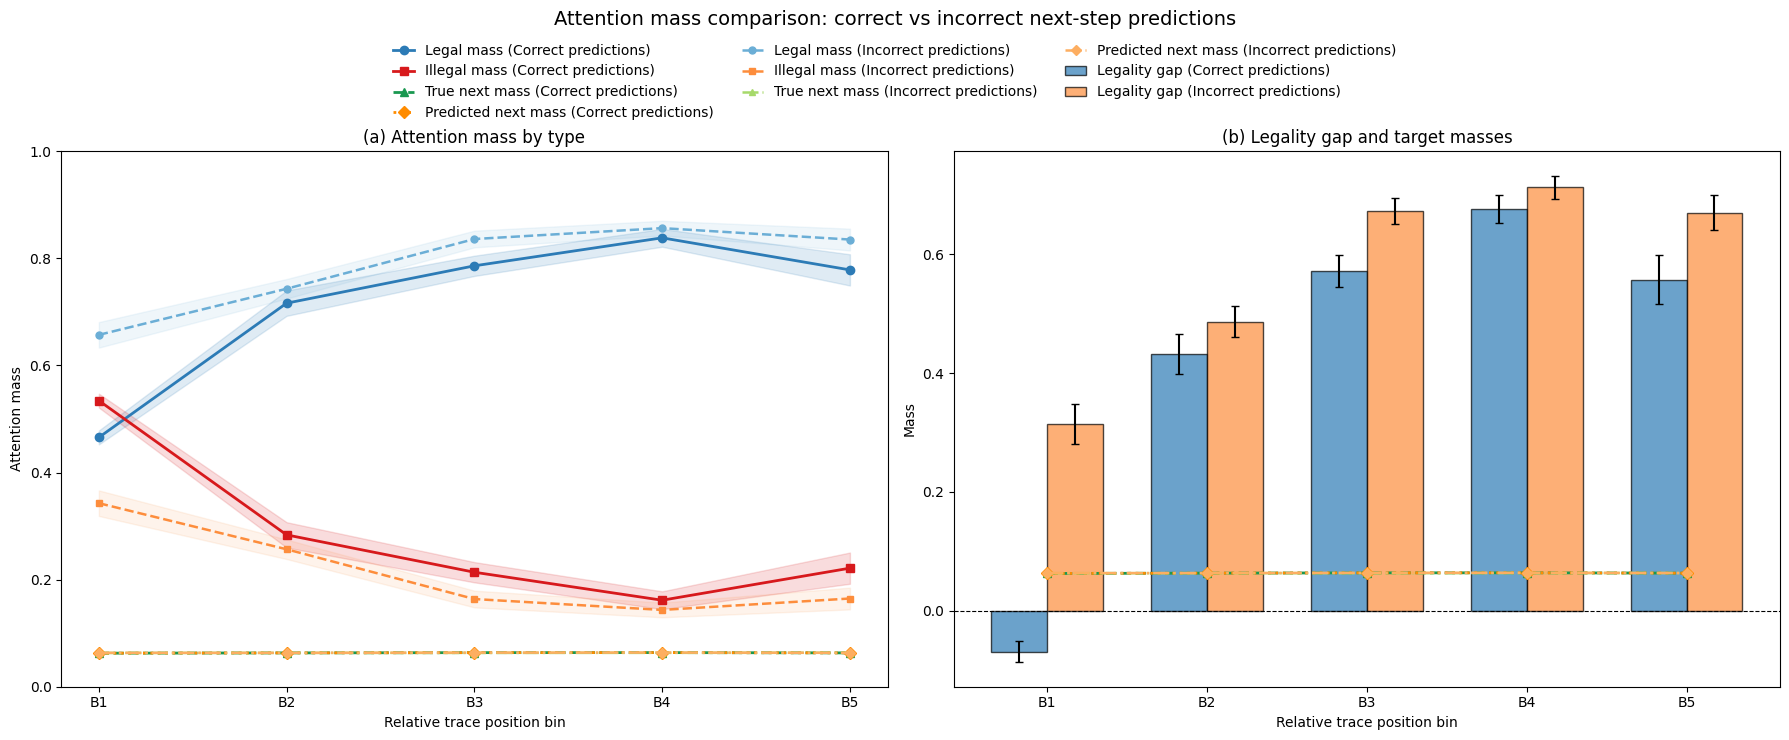

In [43]:

# First, create your two DataFrames
df_mass["next_correct"] = (df_mass["next_true"] == df_mass["next_pred"]).astype(int)

df_correct = df_mass[df_mass["next_correct"] == 1]
df_incorrect = df_mass[df_mass["next_correct"] == 0]

# Plot the comparison
# Plot comparison
plot_combined_attention_mass_comparison(
    df_correct,
    df_incorrect,
    n_bins=5,
    figsize=(18, 7),            # slightly wider to accommodate two groups
    use_sem=True,
    smooth=False,
    group_labels=("Correct predictions", "Incorrect predictions"),
    title="Attention mass comparison: correct vs incorrect next-step predictions",
    save_path="../output/plots/" + dataname + "_attention_mass_compare"
)

Saved: ../output/plots/sepsis_refinement_shift.png  and  ../output/plots/sepsis_refinement_shift.pdf


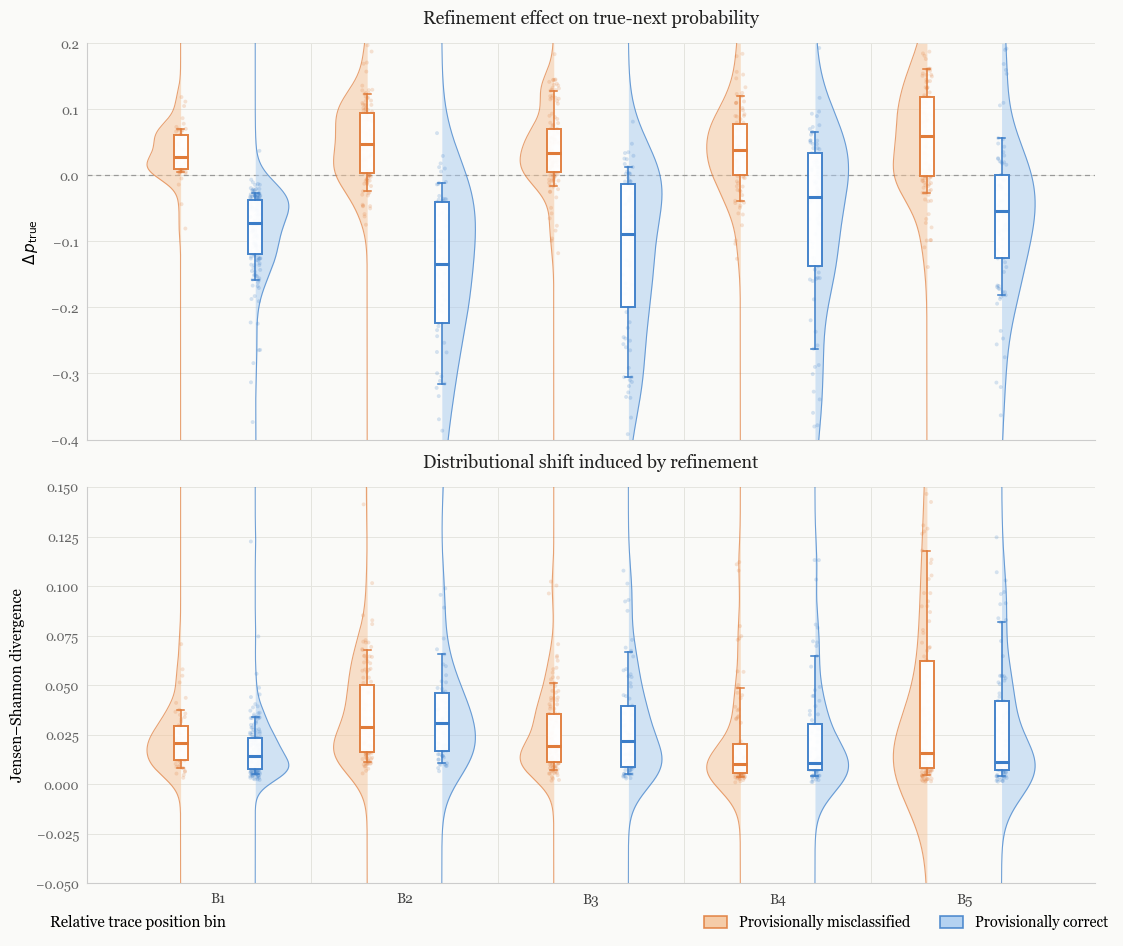

In [46]:
df_ref = build_refinement_shift_table(attn_pack, n_bins=5)
df_ref.to_csv("../output/metrics/" + dataname + "_refinement_shift.csv", index=False)

plot_refinement_raincloud_panel(
    df=df_ref,
    n_bins=5,
    figsize=(13, 10),
    left_group="Provisionally Misclassified",
    right_group="Provisionally Correct",
    left_color="#E07B39",   # warm amber-orange
    right_color="#3B7DC8",   # cool slate-blue
    y_limits_left=(-0.4, 0.2),
    y_limits_right=(-0.05, 0.15),
    zero_line_left=True,
    zero_line_right=False,
    save_path="../output/plots/" + dataname + "_refinement_shift",
    dpi=300)

Saved: ../output/plots/sepsis_decoding_transition.html ../output/plots/sepsis_decoding_transition.pdf and ../output/plots/sepsis_decoding_transition.png


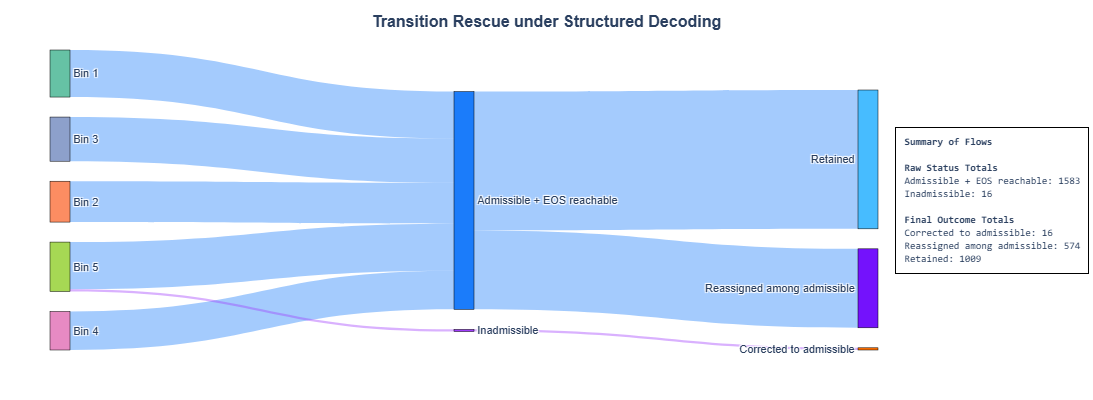

In [47]:
df_rescue.to_csv("../output/metrics/" + dataname + "_decoding_rescue.csv", index=False)
plot_transition_rescue(
    df_rescue,
    n_bins=5,
    figsize=(9, 4),
    title="Transition Rescue under Structured Decoding",
    save_path="../output/plots/" + dataname + "_decoding_transition",
)

Saved: ../output/plots/sepsis_decoding_stack.png and ../output/plots/sepsis_decoding_stack.pdf


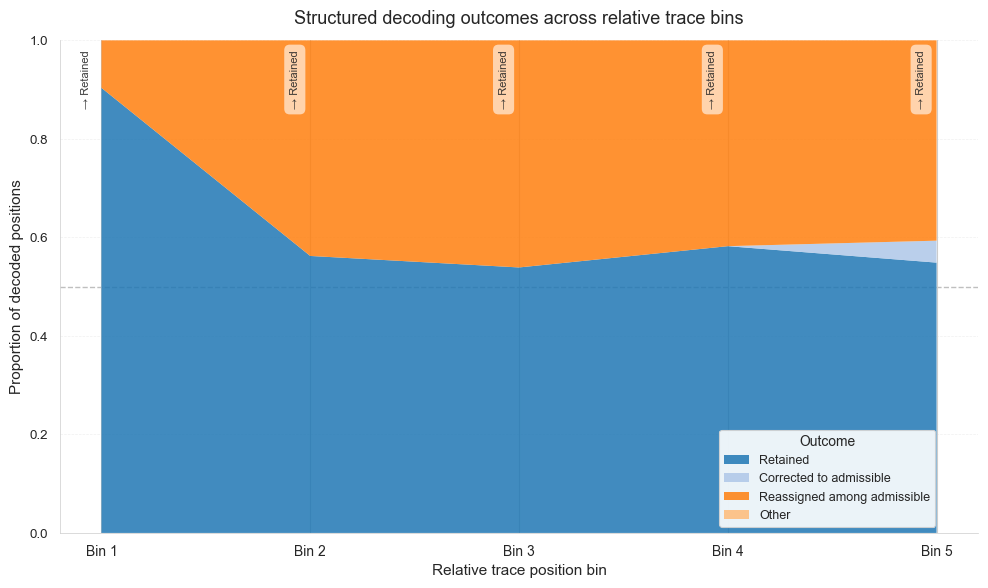

In [48]:
plot_transition_rescue_stacked_area(
    df_rescue,
    n_bins=5,
    title="Structured decoding outcomes across relative trace bins",
    figsize=(10, 6),
    save_path="../output/plots/" + dataname + "_decoding_stack",
    dpi=300,
    color_palette="tab20",
    legend_loc='lower right',
    legend_bbox_to_anchor=(0.96, 0),
    show_annotations=True,
)

In [139]:
import torch

attn = torch.load(attn_save_path, map_location="cpu")

y_true = attn["y_activity"]          # (B, L)
y_pred = attn["pred_activity"]       # (B, L)
mask = attn["mask"].bool()           # (B, L)

eos_id = 2

valid = mask & (y_true != eos_id)

raw_argmax_acc = ((y_pred == y_true) & valid).sum().float() / valid.sum().clamp_min(1).float()
print("Raw argmax no-EOS acc on saved val batch:", raw_argmax_acc.item())

Raw argmax no-EOS acc on saved val batch: 0.8156359195709229
